# 12 — Accuracy Improvement Experiments (LightGBM)

Tests the improvement ideas on the Victorian road crash data, **one change at a time**, against a baseline that mirrors the earlier notebooks.

| Step | Idea |
|---|---|
| E0 | Baseline: the 26 IG-selected features, LightGBM defaults |
| E1 | All leakage-safe features, native categoricals (no IG pruning, no one-hot) |
| E2 | E1 + hand-built domain features |
| E3 | E2 + out-of-fold target encoding of road / LGA history |
| E4 | E3 + light hyper-parameter tuning with early stopping |
| E5 | E4 + class-probability re-weighting (tuned on validation data) |
| E6 | Binary target: Fatal/Serious vs Other |
| E7 | Honesty check: drop `POLICE_ATTEND` |
| E8 | Time-based split (train on earlier years, test on later years) |

The random 80/20 split uses `random_state=42` and stratification, exactly like notebook 03, so the numbers are comparable with the earlier work.
Reference from notebook 11: HistGradientBoosting accuracy 0.6781, macro F1 0.4280.

In [1]:
import warnings, os, re, time
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, log_loss, average_precision_score,
                             roc_auc_score, balanced_accuracy_score, recall_score, precision_score)

SEED = 42
for p in ["../data/victorian_road_crash_data.csv", "/mnt/user-data/uploads/victorian_road_crash_data.csv", "victorian_road_crash_data.csv"]:
    if os.path.exists(p):
        DATA_PATH = p; break
df = pd.read_csv(DATA_PATH)
print(DATA_PATH, df.shape)

/mnt/user-data/uploads/victorian_road_crash_data.csv (200352, 52)


## 1. Clean the target, drop leakage columns, parse date/time

In [2]:
df = df[df["SEVERITY"] != "Non injury accident"].copy()
classes = ["Fatal accident", "Other injury accident", "Serious injury accident"]   # 0,1,2 as in the earlier notebooks
y = df["SEVERITY"].map({c: i for i, c in enumerate(classes)}).astype(int).values

leak = ["INJ_OR_FATAL", "FATALITY", "SERIOUSINJURY", "OTHERINJURY", "NONINJURED"]
df = df.drop(columns=leak + ["SEVERITY"])

# Dates are dd-mm-yyyy in this file; 85 times are malformed (e.g. '21:00.0') -> hour = NaN
d = pd.to_datetime(df["ACCIDENT_DATE"], format="%d-%m-%Y", errors="coerce")
df["YEAR"], df["MONTH"] = d.dt.year, d.dt.month
df["HOUR"] = pd.to_numeric(df["ACCIDENT_TIME"].astype(str).str.extract(r"^(\d{1,2}):\d{2}:\d{2}")[0], errors="coerce")
df["IS_WEEKEND"] = df["DAY_OF_WEEK"].isin(["Saturday", "Sunday"]).astype(int)
print("Years:", df["YEAR"].min(), "-", df["YEAR"].max(), "| class shares:", np.round(np.bincount(y)/len(y), 4))

Years: 2012 - 2025 | class shares: [0.0167 0.6236 0.3596]


## 2. Feature sets

* **Original 26** = the information-gain-selected features from notebook 04.
* **All safe** = every non-leakage column except IDs, raw date/time, redundant coordinates (`VICGRID_*`, `DCA_CODE`) and raw `ROAD_NAME` (thousands of levels; handled through frequency/target encoding instead).
* **Domain features** are hand-built and interpretable.

In [3]:
# frequency encoding of road name (as in notebook 03)
df["ROAD_NAME_FREQ"] = df["ROAD_NAME"].map(df["ROAD_NAME"].value_counts(normalize=True))

def speed_num(s):
    m = re.search(r"(\d+)\s*km", str(s))
    return float(m.group(1)) if m else np.nan
df["SPEED_NUM"] = df["SPEED_ZONE"].map(speed_num)

vru = df[["PEDESTRIAN", "BICYCLIST", "MOTORCYCLIST", "PILLION"]].sum(axis=1)
df["VRU_COUNT"] = vru
df["VRU_INVOLVED"] = (vru > 0).astype(int)
df["VRU_SHARE"] = vru / df["TOTAL_PERSONS"].replace(0, np.nan)
df["SINGLE_VEHICLE"] = (df["NO_OF_VEHICLES"] == 1).astype(int)
df["PERSONS_PER_VEHICLE"] = df["TOTAL_PERSONS"] / df["NO_OF_VEHICLES"].replace(0, np.nan)
df["NIGHT"] = df["LIGHT_CONDITION"].astype(str).str.contains("Dark|Dusk", case=False).astype(int)
df["RUSH_HOUR"] = df["HOUR"].isin([7, 8, 9, 15, 16, 17, 18]).astype(int)
df["HIGH_SPEED"] = (df["SPEED_NUM"] >= 80).astype(int)
df["HIGH_SPEED_SINGLE"] = df["HIGH_SPEED"] * df["SINGLE_VEHICLE"]
df["HIGH_SPEED_VRU"] = df["HIGH_SPEED"] * df["VRU_INVOLVED"]
df["HEAVY_INVOLVED"] = (df["HEAVYVEHICLE"] > 0).astype(int)
df["OFFROAD_NIGHT"] = (df["RUN_OFFROAD"].astype(str).str.lower().eq("yes")).astype(int) * df["NIGHT"]

orig26 = ["POLICE_ATTEND","DCA_CODE_DESCRIPTION","DRIVER","LONGITUDE","ROAD_ROUTE_1","PASSENGERVEHICLE","NO_OF_VEHICLES",
          "LATITUDE","MOTORCYCLIST","ACCIDENT_TYPE","PEDESTRIAN","YOUNG_DRIVER_18_25","RUN_OFFROAD","DEG_URBAN_NAME",
          "MOTORCYCLE","SPEED_ZONE","OLD_DRIVER_75_AND_OVER","TOTAL_PERSONS","OLD_PED_65_AND_OVER","FEMALES","BICYCLIST",
          "MALES","ROAD_NAME_FREQ","PEDESTRIAN"]
orig26 = list(dict.fromkeys(orig26 + ["DCA_CODE", "VICGRID_X", "VICGRID_Y"]))   # notebook 04 also kept these

drop_all = ["ACCIDENT_NO","ACCIDENT_DATE","ACCIDENT_TIME","VICGRID_X","VICGRID_Y","DCA_CODE","ROAD_NAME","YEAR"]
domain = ["SPEED_NUM","VRU_COUNT","VRU_INVOLVED","VRU_SHARE","SINGLE_VEHICLE","PERSONS_PER_VEHICLE","NIGHT","RUSH_HOUR",
          "HIGH_SPEED","HIGH_SPEED_SINGLE","HIGH_SPEED_VRU","HEAVY_INVOLVED","OFFROAD_NIGHT"]
time_feats = ["HOUR","MONTH","IS_WEEKEND"]
all_safe = [c for c in df.columns if c not in drop_all + domain + time_feats]

# category dtype built on the full frame (levels only, no target information)
str_cols = [c for c in df.columns if df[c].dtype == object or str(df[c].dtype).startswith("str")]
for c in str_cols:
    df[c] = df[c].astype("category")

print(len(orig26), "original |", len(all_safe), "all safe |", len(domain), "domain")
print("Categorical columns:", [c for c in str_cols if c in all_safe])

26 original | 40 all safe | 13 domain
Categorical columns: ['ACCIDENT_TYPE', 'DAY_OF_WEEK', 'DCA_CODE_DESCRIPTION', 'LIGHT_CONDITION', 'POLICE_ATTEND', 'ROAD_GEOMETRY', 'SPEED_ZONE', 'RUN_OFFROAD', 'ROAD_TYPE', 'LGA_NAME', 'DTP_REGION', 'DEG_URBAN_NAME', 'SRNS', 'RMA', 'DIVIDED', 'STAT_DIV_NAME']


## 3. Helpers: training with early stopping, metrics, class re-weighting

In [4]:
BASE = dict(objective="multiclass", num_class=3, learning_rate=0.08, num_leaves=63, min_child_samples=40,
            feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5, lambda_l2=5.0,
            seed=SEED, verbosity=-1, num_threads=4)

def fit(X_tr, y_tr, params=None, rounds=2000, es=40, val_frac=0.1, sample_weight=None):
    p = dict(BASE); p.update(params or {})
    Xa, Xv, ya, yv = train_test_split(X_tr, y_tr, test_size=val_frac, stratify=y_tr, random_state=SEED)
    cats = [c for c in X_tr.columns if str(X_tr[c].dtype) == "category"]
    dtr = lgb.Dataset(Xa, ya, categorical_feature=cats or "auto", free_raw_data=False)
    dva = lgb.Dataset(Xv, yv, categorical_feature=cats or "auto", reference=dtr)
    m = lgb.train(p, dtr, rounds, valid_sets=[dva], callbacks=[lgb.early_stopping(es, verbose=False)])
    return m, (Xv, yv)

def metrics(y_true, proba, name):
    pred = proba.argmax(1)
    return {"Experiment": name,
            "Accuracy": accuracy_score(y_true, pred),
            "Macro F1": f1_score(y_true, pred, average="macro"),
            "Log-loss": log_loss(y_true, proba, labels=[0,1,2]),
            "Fatal PR-AUC": average_precision_score(y_true == 0, proba[:, 0]),
            "Fatal recall": recall_score(y_true == 0, pred == 0),
            "Fatal precision": precision_score(y_true == 0, pred == 0, zero_division=0)}

results = []
def record(y_true, proba, name):
    r = metrics(y_true, proba, name); results.append(r)
    print(f"{name:<52} acc={r['Accuracy']:.4f}  macroF1={r['Macro F1']:.4f}  logloss={r['Log-loss']:.4f}  "
          f"fatalPR-AUC={r['Fatal PR-AUC']:.4f}  fatalRec={r['Fatal recall']:.2f}  fatalPrec={r['Fatal precision']:.2f}")

idx = np.arange(len(df))
tr_idx, te_idx = train_test_split(idx, test_size=0.2, random_state=SEED, stratify=y)
print(len(tr_idx), "train /", len(te_idx), "test")
print("Majority-class accuracy on test:", round((y[te_idx] == 1).mean(), 4))

160278 train / 40070 test
Majority-class accuracy on test: 0.6236


## 4. E0 → E2: baseline, all features, domain features

In [5]:
t = time.time()
def run(cols, name, params=None):
    m, val = fit(df.iloc[tr_idx][cols], y[tr_idx], params)
    p = m.predict(df.iloc[te_idx][cols], num_iteration=m.best_iteration)
    record(y[te_idx], p, name); return m, p, val

m0, p0, _ = run(orig26, "E0  original 26 features")
m1, p1, _ = run(all_safe + time_feats, "E1  all safe features + hour/month/weekend")
m2, p2, _ = run(all_safe + time_feats + domain, "E2  E1 + domain features")
print(f"({time.time()-t:.0f}s)")

E0  original 26 features                             acc=0.6748  macroF1=0.4265  logloss=0.6347  fatalPR-AUC=0.1455  fatalRec=0.01  fatalPrec=0.58


E1  all safe features + hour/month/weekend           acc=0.6758  macroF1=0.4274  logloss=0.6344  fatalPR-AUC=0.1497  fatalRec=0.01  fatalPrec=0.70


E2  E1 + domain features                             acc=0.6766  macroF1=0.4339  logloss=0.6336  fatalPR-AUC=0.1457  fatalRec=0.02  fatalPrec=0.72
(41s)


## 5. E3: out-of-fold target encoding of road and LGA history

Road and area severity history is informative, but computing it naively on the training set leaks the target.
Here every training row is encoded from **other folds only** (5-fold), and test rows use the mapping learned on the full training set. Smoothing (m = 20) shrinks rare roads toward the global rate.

In [6]:
def te_maps(keys, targets, prior, m=20):
    g = pd.DataFrame({"k": keys, "t": targets}).groupby("k", observed=True)["t"].agg(["sum", "count"])
    return (g["sum"] + prior * m) / (g["count"] + m)

def add_target_encoding(tr_idx, te_idx, cols=("ROAD_NAME", "LGA_NAME"), n_splits=5):
    out_tr = pd.DataFrame(index=df.index[tr_idx]); out_te = pd.DataFrame(index=df.index[te_idx])
    targets = {"SEVERE": (y != 1).astype(float), "FATAL": (y == 0).astype(float)}
    skf = StratifiedKFold(n_splits, shuffle=True, random_state=SEED)
    raw = pd.read_csv(DATA_PATH, usecols=["ROAD_NAME", "LGA_NAME", "SEVERITY"])
    raw = raw[raw["SEVERITY"] != "Non injury accident"].reset_index(drop=True)
    for col in cols:
        key = raw[col].fillna("NA").astype(str).values
        for tname, tv in targets.items():
            prior = tv[tr_idx].mean(); name = f"TE_{col}_{tname}"
            oof = np.zeros(len(tr_idx))
            for a, b in skf.split(tr_idx, y[tr_idx]):
                mp = te_maps(key[tr_idx][a], tv[tr_idx][a], prior)
                oof[b] = pd.Series(key[tr_idx][b]).map(mp).fillna(prior).values
            out_tr[name] = oof
            mp = te_maps(key[tr_idx], tv[tr_idx], prior)
            out_te[name] = pd.Series(key[te_idx]).map(mp).fillna(prior).values
    return out_tr, out_te

te_tr, te_te = add_target_encoding(tr_idx, te_idx)
te_cols = list(te_tr.columns)
def with_te(cols, part, te):  # attach encodings to a feature frame
    return pd.concat([df.iloc[part][cols], te], axis=1)

feat3 = all_safe + time_feats + domain
Xtr3, Xte3 = with_te(feat3, tr_idx, te_tr), with_te(feat3, te_idx, te_te)
m3, val3 = fit(Xtr3, y[tr_idx])
p3 = m3.predict(Xte3, num_iteration=m3.best_iteration)
record(y[te_idx], p3, "E3  E2 + out-of-fold road/LGA target encoding")

E3  E2 + out-of-fold road/LGA target encoding        acc=0.6773  macroF1=0.4308  logloss=0.6335  fatalPR-AUC=0.1480  fatalRec=0.01  fatalPrec=0.64


## 6. E4: light hyper-parameter search (early stopping, validation log-loss)

In [7]:
t = time.time()
grid = [dict(num_leaves=15, min_child_samples=100, learning_rate=0.05, lambda_l2=10.0),
        dict(num_leaves=31, min_child_samples=60,  learning_rate=0.05, lambda_l2=10.0, feature_fraction=0.6),
        dict(num_leaves=31, min_child_samples=100, learning_rate=0.04, lambda_l2=20.0, feature_fraction=0.6),
        dict(num_leaves=63, min_child_samples=100, learning_rate=0.04, lambda_l2=20.0, feature_fraction=0.5),
        dict(num_leaves=127, min_child_samples=200, learning_rate=0.03, lambda_l2=30.0, feature_fraction=0.5),
        dict(num_leaves=7,  min_child_samples=50,  learning_rate=0.06, lambda_l2=5.0,  feature_fraction=0.7)]
rows = []
for i, g in enumerate(grid):
    m, (Xv, yv) = fit(Xtr3, y[tr_idx], g)
    ll = log_loss(yv, m.predict(Xv, num_iteration=m.best_iteration), labels=[0,1,2])
    rows.append({**g, "val_logloss": ll, "best_iter": m.best_iteration}); print(i, round(ll, 5), m.best_iteration)
tune = pd.DataFrame(rows).sort_values("val_logloss"); display(tune)
best = {k: v for k, v in tune.iloc[0].to_dict().items() if k not in ("val_logloss", "best_iter") and pd.notna(v)}
best["num_leaves"] = int(best["num_leaves"]); best["min_child_samples"] = int(best["min_child_samples"])
m4, val4 = fit(Xtr3, y[tr_idx], best)
p4 = m4.predict(Xte3, num_iteration=m4.best_iteration)
record(y[te_idx], p4, "E4  E3 + tuned LightGBM")
print(f"({time.time()-t:.0f}s)  best params: {best}")

0 0.63906 194


1 0.63758 188


2 0.63822 271


3 0.6374 217


4 0.63772 229


5 0.63865 276


,num_leaves,min_child_samples,learning_rate,lambda_l2,val_logloss,best_iter,feature_fraction
3,63,100,0.04,20.0,0.637400,217,0.5
1,31,60,0.05,10.0,0.637579,188,0.6
4,127,200,0.03,30.0,0.637721,229,0.5
2,31,100,0.04,20.0,0.638215,271,0.6
5,7,50,0.06,5.0,0.638646,276,0.7
0,15,100,0.05,10.0,0.639056,194,NaN


E4  E3 + tuned LightGBM                              acc=0.6789  macroF1=0.4318  logloss=0.6308  fatalPR-AUC=0.1563  fatalRec=0.01  fatalPrec=0.69
(258s)  best params: {'num_leaves': 63, 'min_child_samples': 100, 'learning_rate': 0.04, 'lambda_l2': 20.0, 'feature_fraction': 0.5}


## 7. E5: re-weight class probabilities

The multiplier grid is fitted on the validation hold-out (never the test set) to maximise macro F1, then applied unchanged to the test set.
This trades plain accuracy for better Fatal/Serious detection, so both are shown.

In [8]:
Xv4, yv4 = val4
pv = m4.predict(Xv4, num_iteration=m4.best_iteration)
best_w, best_f = (1.0, 1.0), -1
for wf in [1, 2, 4, 6, 8, 12, 16, 24, 32]:
    for ws in [0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.5, 1.7, 2.0]:
        f = f1_score(yv4, (pv * np.array([wf, 1.0, ws])).argmax(1), average="macro")
        if f > best_f: best_f, best_w = f, (wf, ws)
print("Best weights (Fatal, Serious):", best_w, "| val macro F1:", round(best_f, 4))
p5 = p4 * np.array([best_w[0], 1.0, best_w[1]]); p5 = p5 / p5.sum(1, keepdims=True)
record(y[te_idx], p5, "E5  E4 + class re-weighting (macro-F1 tuned)")

# accuracy-preserving alternative: only allow weights that keep validation accuracy within 1 point of E4
base_acc = accuracy_score(yv4, pv.argmax(1)); alt_w, alt_f = (1.0, 1.0), -1
for wf in [1, 1.5, 2, 3, 4, 6]:
    for ws in [0.9, 1.0, 1.1, 1.2, 1.3]:
        pr = (pv * np.array([wf, 1.0, ws])).argmax(1)
        if accuracy_score(yv4, pr) >= base_acc - 0.01:
            f = f1_score(yv4, pr, average="macro")
            if f > alt_f: alt_f, alt_w = f, (wf, ws)
p5b = p4 * np.array([alt_w[0], 1.0, alt_w[1]]); p5b = p5b / p5b.sum(1, keepdims=True)
record(y[te_idx], p5b, f"E5b E4 + mild re-weighting {alt_w} (acc-constrained)")

Best weights (Fatal, Serious): (8, 1.5) | val macro F1: 0.4969
E5  E4 + class re-weighting (macro-F1 tuned)         acc=0.6492  macroF1=0.4983  logloss=0.6896  fatalPR-AUC=0.1553  fatalRec=0.29  fatalPrec=0.16


E5b E4 + mild re-weighting (4, 1.2) (acc-constrained) acc=0.6688  macroF1=0.4828  logloss=0.6511  fatalPR-AUC=0.1558  fatalRec=0.13  fatalPrec=0.20


## 8. E6: binary target — Fatal/Serious (severe) vs Other injury

In [9]:
yb = (y != 1).astype(int)
def fit_bin(X, yy, params):
    p = dict(BASE); p.update(params); p.update(objective="binary", metric="binary_logloss"); p.pop("num_class")
    Xa, Xv, ya, yv = train_test_split(X, yy, test_size=0.1, stratify=yy, random_state=SEED)
    cats = [c for c in X.columns if str(X[c].dtype) == "category"]
    d1 = lgb.Dataset(Xa, ya, categorical_feature=cats or "auto"); d2 = lgb.Dataset(Xv, yv, categorical_feature=cats or "auto", reference=d1)
    m = lgb.train(p, d1, 2000, valid_sets=[d2], callbacks=[lgb.early_stopping(40, verbose=False)])
    return m, Xv, yv
mb, Xvb, yvb = fit_bin(Xtr3, yb[tr_idx], best)
pb = mb.predict(Xte3, num_iteration=mb.best_iteration)
maj = max(yb[te_idx].mean(), 1 - yb[te_idx].mean())
# threshold picked on validation to maximise balanced accuracy
pvb = mb.predict(Xvb, num_iteration=mb.best_iteration)
ths = np.linspace(0.2, 0.7, 51); th = ths[np.argmax([balanced_accuracy_score(yvb, pvb > t) for t in ths])]
bin_res = pd.DataFrame([
    {"Setting": "Majority-class guess", "Accuracy": maj, "Balanced acc": 0.5, "ROC-AUC": 0.5},
    {"Setting": "LightGBM @0.5", "Accuracy": accuracy_score(yb[te_idx], pb > .5), "Balanced acc": balanced_accuracy_score(yb[te_idx], pb > .5), "ROC-AUC": roc_auc_score(yb[te_idx], pb)},
    {"Setting": f"LightGBM @{th:.2f} (val-tuned)", "Accuracy": accuracy_score(yb[te_idx], pb > th), "Balanced acc": balanced_accuracy_score(yb[te_idx], pb > th), "ROC-AUC": roc_auc_score(yb[te_idx], pb)}])
display(bin_res.round(4))

,Setting,Accuracy,Balanced acc,ROC-AUC
0,Majority-class guess,0.6236,0.5000,0.5000
1,LightGBM @0.5,0.6917,0.6480,0.7398
2,LightGBM @0.39 (val-tuned),0.6695,0.6733,0.7398


## 9. E7: honesty check — drop `POLICE_ATTEND`

In [10]:
feat7 = [c for c in feat3 if c != "POLICE_ATTEND"]
m7, _ = fit(pd.concat([df.iloc[tr_idx][feat7], te_tr], axis=1), y[tr_idx], best)
p7 = m7.predict(pd.concat([df.iloc[te_idx][feat7], te_te], axis=1), num_iteration=m7.best_iteration)
record(y[te_idx], p7, "E7  E4 without POLICE_ATTEND")

E7  E4 without POLICE_ATTEND                         acc=0.6641  macroF1=0.4144  logloss=0.6528  fatalPR-AUC=0.1491  fatalRec=0.02  fatalPrec=0.69


## 10. E8: time-based split

Train on crashes up to and including 2021, test on 2022 onward. A random split lets the model see crashes from the same months and roads it is tested on; a time split is closer to real deployment.

In [11]:
yr = pd.to_datetime(pd.read_csv(DATA_PATH, usecols=["ACCIDENT_DATE", "SEVERITY"]).query("SEVERITY != 'Non injury accident'")["ACCIDENT_DATE"], format="%d-%m-%Y").dt.year.values
tr_t = np.where(yr <= 2021)[0]; te_t = np.where(yr >= 2022)[0]
print(len(tr_t), "train /", len(te_t), "test | majority acc on test:", round((y[te_t] == 1).mean(), 4))
te_tr_t, te_te_t = add_target_encoding(tr_t, te_t)
Xtr_t, Xte_t = with_te(feat3, tr_t, te_tr_t), with_te(feat3, te_t, te_te_t)
mt, _ = fit(Xtr_t, y[tr_t], best)
pt = mt.predict(Xte_t, num_iteration=mt.best_iteration)
record(y[te_t], pt, "E8  E4 setup, TIME split (train<=2021, test>=2022)")
m0t, _ = fit(df.iloc[tr_t][orig26], y[tr_t])
record(y[te_t], m0t.predict(df.iloc[te_t][orig26], num_iteration=m0t.best_iteration), "E8b E0 features, TIME split")

140597 train / 59751 test | majority acc on test: 0.6513


E8  E4 setup, TIME split (train<=2021, test>=2022)   acc=0.6865  macroF1=0.4321  logloss=0.6201  fatalPR-AUC=0.1548  fatalRec=0.01  fatalPrec=0.52


E8b E0 features, TIME split                          acc=0.6836  macroF1=0.4290  logloss=0.6230  fatalPR-AUC=0.1491  fatalRec=0.01  fatalPrec=0.54


## 11. Summary

,Accuracy,Macro F1,Log-loss,Fatal PR-AUC,Fatal recall,Fatal precision
Experiment,,,,,,
REF notebook 11: HistGB + interactions,0.6784,0.4284,NaN,NaN,NaN,NaN
E0 original 26 features,0.6748,0.4265,0.6347,0.1455,0.0104,0.5833
E1 all safe features + hour/month/weekend,0.6758,0.4274,0.6344,0.1497,0.0104,0.7000
E2 E1 + domain features,0.6766,0.4339,0.6336,0.1457,0.0194,0.7222
E3 E2 + out-of-fold road/LGA target encoding,0.6773,0.4308,0.6335,0.1480,0.0134,0.6429
E4 E3 + tuned LightGBM,0.6789,0.4318,0.6308,0.1563,0.0134,0.6923
E5 E4 + class re-weighting (macro-F1 tuned),0.6492,0.4983,0.6896,0.1553,0.2896,0.1647
"E5b E4 + mild re-weighting (4, 1.2) (acc-constrained)",0.6688,0.4828,0.6511,0.1558,0.1343,0.2036
E7 E4 without POLICE_ATTEND,0.6641,0.4144,0.6528,0.1491,0.0164,0.6875


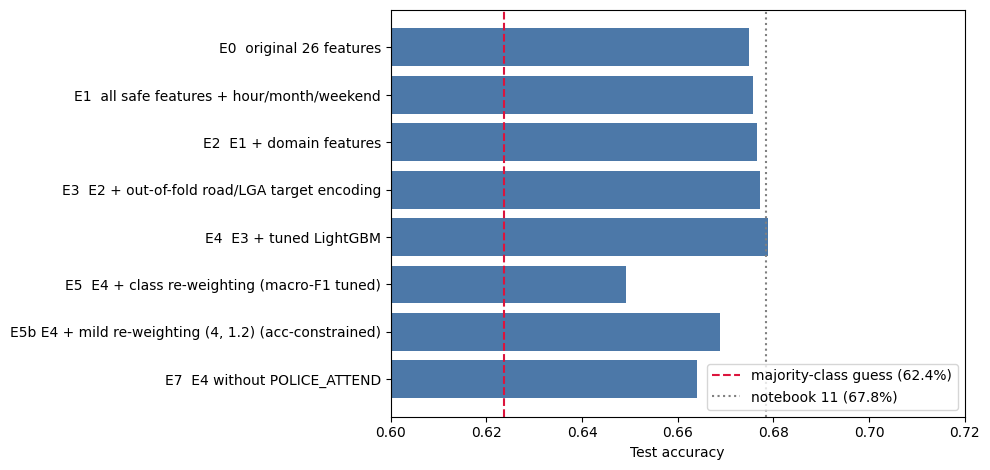

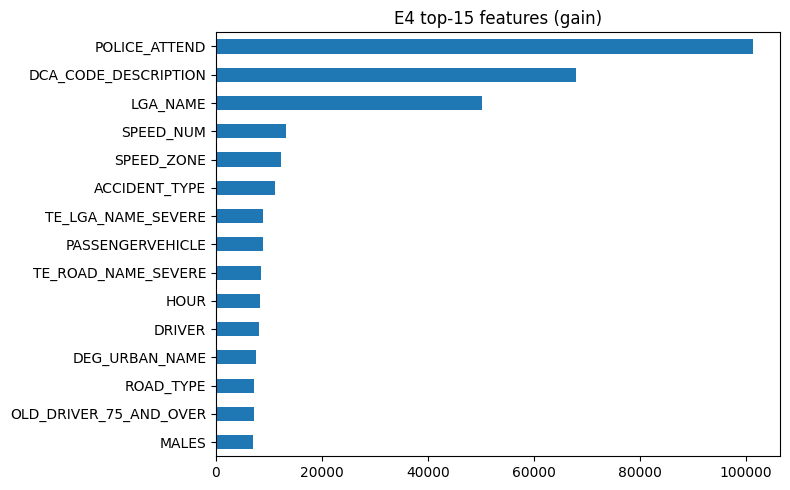

In [12]:
res = pd.DataFrame(results).set_index("Experiment")
ref = pd.DataFrame([{"Experiment": "REF notebook 11: HistGB + interactions", "Accuracy": 0.6784, "Macro F1": 0.4284}]).set_index("Experiment")
display(pd.concat([ref, res]).round(4))

fig, ax = plt.subplots(figsize=(10, 4.8))
sub = res[~res.index.str.startswith(("E8",))]
ax.barh(sub.index[::-1], sub["Accuracy"][::-1], color="#4c78a8")
ax.axvline(0.6236, color="crimson", ls="--", label="majority-class guess (62.4%)"); ax.axvline(0.6784, color="gray", ls=":", label="notebook 11 (67.8%)")
ax.set_xlim(0.60, max(0.72, sub["Accuracy"].max() + 0.01)); ax.set_xlabel("Test accuracy"); ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

imp = pd.Series(m4.feature_importance("gain"), index=m4.feature_name()).sort_values(ascending=False).head(15)
imp[::-1].plot.barh(figsize=(8, 5), title="E4 top-15 features (gain)"); plt.tight_layout(); plt.show()